In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/subarnamallick/solarsis/dataset-consulting-strategy (1).xlsx


In [2]:
df= pd.read_excel('/kaggle/input/datasets/subarnamallick/solarsis/dataset-consulting-strategy (1).xlsx')
df.head()

,CASE_KEY,DELIVERY_COMPANY,PRODUCT_TYPE,FACTORY,ORDERED_QUANTITY,DELIVERED_QUANTITY,MIN_ORDER_TOLERANCE,MAX_ORDER_TOLERANCE,CUST_MARKET,CUST_ID,...,ORDER_TOLERANCE_MET,ORDER_DATE_MET,X_CEL_O2C_CASES.SAL_ORD_POS_QUAN,DELIVERED_QUANTITY_UNIT,WAREHOUSE_TYPE,DELIVERED_DATE,PROMISED_DATE,CUST_COUNTRY,ORDER_VALUE,UNIT_PRICE
0,11100091.0,BlueDart,Eco-Battery,Bengaluru,101.0,101.0,0.0,0.0,Retail,35755.0,...,1.0,1.0,101.0,kg,Standard Hub,2018-02-08 00:00:01,2018-02-08 00:00:01,IN,59702.4,591.3
1,11100191.0,BlueDart,Eco-Battery,Bengaluru,308.0,308.0,0.0,0.0,Retail,35755.0,...,1.0,1.0,308.0,kg,Standard Hub,2018-02-01 00:00:01,2018-01-30 00:00:01,IN,185772.6,603.0
2,11100192.0,BlueDart,Eco-Battery,Bengaluru,1130.0,1130.0,0.0,0.0,Retail,35755.0,...,1.0,0.0,1130.0,kg,Standard Hub,2018-02-01 00:00:01,2018-02-05 00:00:01,IN,683935.2,605.7
3,11100291.0,BlueDart,Eco-Battery,Bengaluru,161.0,161.0,0.0,0.0,Retail,37789.0,...,1.0,1.0,161.0,kg,Standard Hub,2018-01-30 00:00:01,2018-01-30 00:00:01,IN,228420.0,1418.4
4,11100391.0,BlueDart,Titan Inverter,Pune,2000.0,2330.0,-20.0,20.0,Retail,93955.0,...,0.0,1.0,2330.0,kg,Standard Hub,2018-02-06 00:00:01,2018-02-06 00:00:01,IN,1321110.0,567.0


In [3]:
bluedart_df = df.loc[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'bluedart',['DELIVERY_COMPANY', 'ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries = bluedart_df.shape[0]
print("Total number of BlueDart deliveries:", total_deliveries)
on_time_deliveries = (bluedart_df['ORDER_DATE_MET'] == 1).sum()
print("Total number of on-time deliveries:", on_time_deliveries)
counts = bluedart_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate = (on_time_deliveries / total_deliveries) * 100
print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")


Total number of BlueDart deliveries: 17956
Total number of on-time deliveries: 16140
ORDER_DATE_MET
1.0    16140
0.0     1816
Name: count, dtype: int64
On-Time Delivery Rate: 89.89%


In [4]:
delhivery_df= df.loc[df['DELIVERY_COMPANY'].str.strip().str.lower()=='delhivery',['DELIVERY_COMPANY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= delhivery_df.shape[0]
print("total number of delhivery deliveries:",total_deliveries)
on_time_deliveries =(delhivery_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= delhivery_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")
performance_gap= 80- on_time_rate
print(f"performance gap:{performance_gap:f}%")


total number of delhivery deliveries: 1259
total number of on time deliveries: 659
ORDER_DATE_MET
1.0    659
0.0    600
Name: count, dtype: int64
On time delivery rate:52.343129%
performance gap:27.656871%


In [5]:
fedex_df= df.loc[df['DELIVERY_COMPANY'].str.strip().str.lower()=='fedex',['DELIVERY_COMPANY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= fedex_df.shape[0]
print("total number of fedex deliveries:",total_deliveries)
on_time_deliveries =(fedex_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= fedex_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")


total number of fedex deliveries: 722
total number of on time deliveries: 611
ORDER_DATE_MET
1.0    611
0.0    111
Name: count, dtype: int64
On time delivery rate:84.626039%


In [6]:
schenker_df= df.loc[df['DELIVERY_COMPANY'].str.strip().str.lower()=='db schenker',['DELIVERY_COMPANY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= schenker_df.shape[0]
print("total number of schenker deliveries:",total_deliveries)
on_time_deliveries =(schenker_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= schenker_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of schenker deliveries: 16
total number of on time deliveries: 16
ORDER_DATE_MET
1.0    16
Name: count, dtype: int64
On time delivery rate:100.000000%


In [7]:
titan_df= df.loc[df['PRODUCT_TYPE'].str.strip().str.lower()=='titan inverter',['PRODUCT_TYPE','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= titan_df.shape[0]
print("total number of delhivery deliveries:",total_deliveries)
on_time_deliveries =(titan_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= titan_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")
performance_gap= 80- on_time_rate
print(f"performance gap:{performance_gap:f}%")

total number of delhivery deliveries: 10419
total number of on time deliveries: 8416
ORDER_DATE_MET
1.0    8416
0.0    2003
Name: count, dtype: int64
On time delivery rate:80.775506%
performance gap:-0.775506%


In [8]:
eco_df= df.loc[df['PRODUCT_TYPE'].str.strip().str.lower()=='eco-battery',['PRODUCT_TYPE','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= eco_df.shape[0]
print("total number of delhivery deliveries:",total_deliveries)
on_time_deliveries =(eco_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= eco_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of delhivery deliveries: 9534
total number of on time deliveries: 9010
ORDER_DATE_MET
1.0    9010
0.0     524
Name: count, dtype: int64
On time delivery rate:94.503881%


In [9]:
bengaluru_df= df.loc[df['FACTORY'].str.strip().str.lower()=='bengaluru',['FACTORY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= bengaluru_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(bengaluru_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= bengaluru_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of deliveries: 8138
total number of on time deliveries: 7621
ORDER_DATE_MET
1.0    7621
0.0     517
Name: count, dtype: int64
On time delivery rate:93.647088%


In [10]:
pune_df= df.loc[df['FACTORY'].str.strip().str.lower()=='pune',['FACTORY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= pune_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(pune_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= pune_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of deliveries: 9093
total number of on time deliveries: 7441
ORDER_DATE_MET
1.0    7441
0.0    1652
Name: count, dtype: int64
On time delivery rate:81.832179%


In [11]:
hyderabad_df= df.loc[df['FACTORY'].str.strip().str.lower()=='hyderabad',['FACTORY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= hyderabad_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(hyderabad_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= hyderabad_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of deliveries: 1415
total number of on time deliveries: 1230
ORDER_DATE_MET
1.0    1230
0.0     185
Name: count, dtype: int64
On time delivery rate:86.925795%


In [12]:
bonn_df= df.loc[df['FACTORY'].str.strip().str.lower()=='bonn',['FACTORY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= bonn_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(bonn_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= bonn_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of deliveries: 1166
total number of on time deliveries: 1007
ORDER_DATE_MET
1.0    1007
0.0     159
Name: count, dtype: int64
On time delivery rate:86.363636%


In [13]:
duisburg_df= df.loc[df['FACTORY'].str.strip().str.lower()=='duisburg',['FACTORY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= duisburg_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(duisburg_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= duisburg_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of deliveries: 133
total number of on time deliveries: 121
ORDER_DATE_MET
1.0    121
0.0     12
Name: count, dtype: int64
On time delivery rate:90.977444%


In [14]:
wuppertal_df= df.loc[df['FACTORY'].str.strip().str.lower()=='wuppertal',['FACTORY','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= wuppertal_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(wuppertal_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= wuppertal_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")
performance_gap= 80- on_time_rate
print(f"performance gap:{performance_gap:f}%")

total number of deliveries: 8
total number of on time deliveries: 6
ORDER_DATE_MET
1.0    6
0.0    2
Name: count, dtype: int64
On time delivery rate:75.000000%
performance gap:5.000000%


In [15]:
retail_df= df.loc[df['CUST_MARKET'].str.strip().str.lower()=='retail',['CUST_MARKET','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= retail_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(retail_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= retail_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of deliveries: 11924
total number of on time deliveries: 11107
ORDER_DATE_MET
1.0    11107
0.0      817
Name: count, dtype: int64
On time delivery rate:93.148272%


In [16]:
transportation_df= df.loc[df['CUST_MARKET'].str.strip().str.lower()=='transportation',['CUST_MARKET','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= transportation_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(transportation_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= transportation_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")
performance_gap= 80- on_time_rate
print(f"performance gap:{performance_gap:f}%")

total number of deliveries: 6092
total number of on time deliveries: 4736
ORDER_DATE_MET
1.0    4736
0.0    1356
Name: count, dtype: int64
On time delivery rate:77.741300%
performance gap:2.258700%


In [17]:
construction_df= df.loc[df['CUST_MARKET'].str.strip().str.lower()=='construction',['CUST_MARKET','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= construction_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(construction_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= construction_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of deliveries: 1683
total number of on time deliveries: 1368
ORDER_DATE_MET
1.0    1368
0.0     315
Name: count, dtype: int64
On time delivery rate:81.283422%


In [18]:
other_df= df.loc[df['CUST_MARKET'].str.strip().str.lower()=='other',['CUST_MARKET','ORDER_DATE_MET']].reset_index(drop=True)
total_deliveries= other_df.shape[0]
print("total number of deliveries:",total_deliveries)
on_time_deliveries =(other_df['ORDER_DATE_MET']==1).sum()
print("total number of on time deliveries:", on_time_deliveries)
counts= other_df['ORDER_DATE_MET'].value_counts()
print(counts)
on_time_rate=(on_time_deliveries/total_deliveries)*100
print(f"On time delivery rate:{on_time_rate:2f}%")

total number of deliveries: 254
total number of on time deliveries: 215
ORDER_DATE_MET
1.0    215
0.0     39
Name: count, dtype: int64
On time delivery rate:84.645669%


In [19]:
filtered_df = df[df['CUST_MARKET'].str.strip().str.lower() == 'transportation'] 
m_values = pd.to_numeric(filtered_df['DAYS_TO_DEL_DEADLINE'], errors='coerce').abs()
total_sum = m_values.sum()
final_result = total_sum * 5000
print("Final Result:", final_result)

Final Result: 149630000.0


In [20]:
filtered_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'delhivery'] 
m_values = pd.to_numeric(filtered_df['DAYS_TO_DEL_DEADLINE'], errors='coerce').abs()
total_sum = m_values.sum()
final_result = total_sum * 5000
print("Final Result:", final_result)

Final Result: 45295000.0


In [21]:
filtered_df = df[df['PRODUCT_TYPE'].str.strip().str.lower() == 'titan inverter'] 
m_values = pd.to_numeric(filtered_df['DAYS_TO_DEL_DEADLINE'], errors='coerce').abs()
total_sum = m_values.sum()
final_result = total_sum * 5000
print("Final Result:", final_result)

Final Result: 205820000.0


In [22]:
filtered_df = df[df['FACTORY'].str.strip().str.lower() == 'wuppertal'] 
m_values = pd.to_numeric(filtered_df['DAYS_TO_DEL_DEADLINE'], errors='coerce').abs()
total_sum = m_values.sum()
final_result = total_sum * 5000
print("Final Result:", final_result)

Final Result: 165000.0


In [23]:
delhivery_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'delhivery']
product_counts = delhivery_df['PRODUCT_TYPE'].value_counts()
print(product_counts)

PRODUCT_TYPE
Titan Inverter    951
Eco-Battery       308
Name: count, dtype: int64


In [24]:
bluedart_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'bluedart']
product_counts = bluedart_df['PRODUCT_TYPE'].value_counts()
print(product_counts)

PRODUCT_TYPE
Titan Inverter    9081
Eco-Battery       8875
Name: count, dtype: int64


In [25]:
fedex_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'fedex']
product_counts = fedex_df['PRODUCT_TYPE'].value_counts()
print(product_counts)

PRODUCT_TYPE
Titan Inverter    374
Eco-Battery       348
Name: count, dtype: int64


In [26]:
schenker_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'db schenker']
product_counts = schenker_df['PRODUCT_TYPE'].value_counts()
print(product_counts)

PRODUCT_TYPE
Titan Inverter    13
Eco-Battery        3
Name: count, dtype: int64


In [27]:
delhivery_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'delhivery']
average_quantity = delhivery_df['ORDERED_QUANTITY'].mean()
print("Average ORDERED_QUANTITY for Delhivery:", average_quantity)

Average ORDERED_QUANTITY for Delhivery: 4427.602859412232


In [28]:
bluedart_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'bluedart']
average_quantity = bluedart_df['ORDERED_QUANTITY'].mean()
print("Average ORDERED_QUANTITY for Bluedart:", average_quantity)

Average ORDERED_QUANTITY for Bluedart: 2227.793383827133


In [29]:
fedex_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'fedex']
average_quantity = fedex_df['ORDERED_QUANTITY'].mean()
print("Average ORDERED_QUANTITY for Fedex:", average_quantity)

Average ORDERED_QUANTITY for Fedex: 2883.7548476454294


In [30]:
schenker_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'db schenker']
average_quantity = schenker_df['ORDERED_QUANTITY'].mean()
print("Average ORDERED_QUANTITY for DB Schenker:", average_quantity)

Average ORDERED_QUANTITY for DB Schenker: 13475.1875


In [31]:
delhivery_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'delhivery']
warehouse_counts= delhivery_df['WAREHOUSE_TYPE'].value_counts()
print(warehouse_counts)

WAREHOUSE_TYPE
Standard Hub       1258
Smart Warehouse       1
Name: count, dtype: int64


In [32]:
bluedart_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'bluedart']
warehouse_counts= bluedart_df['WAREHOUSE_TYPE'].value_counts()
print(warehouse_counts)

WAREHOUSE_TYPE
Standard Hub       17908
Smart Warehouse       48
Name: count, dtype: int64


In [33]:
fedex_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'fedex']
warehouse_counts= fedex_df['WAREHOUSE_TYPE'].value_counts()
print(warehouse_counts)

WAREHOUSE_TYPE
Standard Hub    722
Name: count, dtype: int64


In [34]:
schenker_df = df[df['DELIVERY_COMPANY'].str.strip().str.lower() == 'db schenker']
warehouse_counts= schenker_df['WAREHOUSE_TYPE'].value_counts()
print(warehouse_counts)

WAREHOUSE_TYPE
Standard Hub    16
Name: count, dtype: int64


In [35]:
avg_orders_by_product = (df.groupby('PRODUCT_TYPE')['ORDERED_QUANTITY'].mean().reset_index(name='AVG_ORDERED_QUANTITY'))

print(avg_orders_by_product)

     PRODUCT_TYPE  AVG_ORDERED_QUANTITY
0     Eco-Battery            556.909167
1  Titan Inverter           4085.297245


In [36]:
avg_order_value = (df.groupby('PRODUCT_TYPE')['ORDER_VALUE'].mean().reset_index(name='AVERAGE_ORDER_VALUE'))

print(avg_order_value)

     PRODUCT_TYPE  AVERAGE_ORDER_VALUE
0     Eco-Battery         2.222788e+06
1  Titan Inverter         6.878653e+07


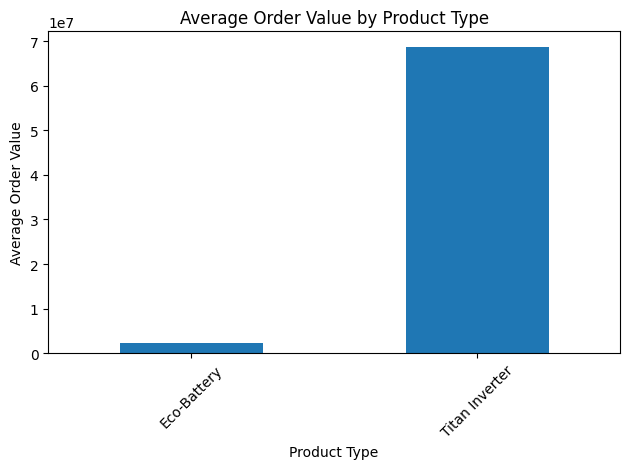

In [37]:
import matplotlib.pyplot as plt

avg_order_value.set_index('PRODUCT_TYPE')['AVERAGE_ORDER_VALUE'].plot(kind='bar')
plt.title('Average Order Value by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()